In [16]:
#!pip install --upgrade langchain langchain-community

In [ ]:
from typing_extensions import TypedDict
from typing import List, Dict, Any
import re

from langgraph.graph.state import StateGraph, START, END
from langchain_aws import ChatBedrockConverse
from langchain_core.messages import HumanMessage


# -----------------------------
# Demo Retail Catalog
# -----------------------------
CATALOG = [
    {"name": "Nova Earbuds", "category": "earbuds", "price": 1999, "rating": 4.4},
    {"name": "BassMax Earbuds", "category": "earbuds", "price": 2999, "rating": 4.6},
    {"name": "FitBand Pro", "category": "fitness", "price": 3499, "rating": 4.5},
    {"name": "SmartWatch Mini", "category": "watch", "price": 3999, "rating": 4.3},
]



# -----------------------------
# LLM setup (AWS Bedrock)
# -----------------------------
llm = ChatBedrockConverse(
    model_id="amazon.nova-lite-v1:0",
    region_name="us-east-1",
    temperature=0.7,
    max_tokens=100
)



# -----------------------------
# Graph State
# -----------------------------
class RetailState(TypedDict, total=False):
    query: str
    category: str
    budget: int
    products: List[Dict[str, Any]]
    recommendation: str


# -----------------------------
# Agent 1: Intent Agent
# -----------------------------
def intent_agent(state: RetailState) -> RetailState:
    q = state["query"].lower()

    category = "earbuds" if "earbud" in q else "watch"
    match = re.search(r"(\d{3,7})", q.replace(",", ""))
    budget = int(match.group(1)) if match else 3000

    return {"category": category, "budget": budget}


# -----------------------------
# Agent 2: Catalog Agent
# -----------------------------
def catalog_agent(state: RetailState) -> RetailState:
    results = [
        p for p in CATALOG
        if p["category"] == state["category"]
        and p["price"] <= state["budget"]
    ]
    results.sort(key=lambda x: x["rating"], reverse=True)
    return {"products": results}


# -----------------------------
# Agent 3: Advisor Agent (LLM)
# -----------------------------
def advisor_agent(state: RetailState) -> RetailState:
    if not state["products"]:
        return {"recommendation": "No suitable products found."}

    items = "\n".join(
        f"- {p['name']} (₹{p['price']}, rating {p['rating']})"
        for p in state["products"]
    )

    prompt = (
        f"User query: {state['query']}\n"
        f"Products:\n{items}\n\n"
        "Recommend the best option in 2 short sentences."
    )

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"recommendation": response.content}


# -----------------------------
# Build Graph
# -----------------------------
graph = (
    StateGraph(RetailState)
    .add_node("intent_agent", intent_agent)
    .add_node("catalog_agent", catalog_agent)
    .add_node("advisor_agent", advisor_agent)
    .add_edge(START, "intent_agent")
    .add_edge("intent_agent", "catalog_agent")
    .add_edge("catalog_agent", "advisor_agent")
    .add_edge("advisor_agent", END)
    .compile()
)

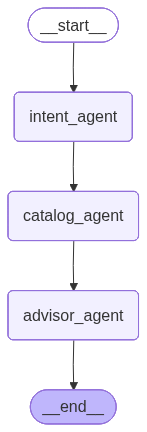

In [11]:
graph

In [12]:
for chunk in graph.stream(
    {"query": "Suggest earbuds under 3000"},
    stream_mode="values",
    version="v2",
):
    if chunk["type"] == "values":
        print(chunk["data"])

{'query': 'Suggest earbuds under 3000'}

{'query': 'Suggest earbuds under 3000', 'category': 'earbuds', 'budget': 3000}

{
    'query': 'Suggest earbuds under 3000',
    'category': 'earbuds',
    'budget': 3000,
    'products': [
        {'name': 'BassMax Earbuds', 'category': 'earbuds', 'price': 2999, 'rating': 4.6},
        {'name': 'Nova Earbuds', 'category': 'earbuds', 'price': 1999, 'rating': 4.4}
    ]
}

{
    'query': 'Suggest earbuds under 3000',
    'category': 'earbuds',
    'budget': 3000,
    'products': [
        {'name': 'BassMax Earbuds', 'category': 'earbuds', 'price': 2999, 'rating': 4.6},
        {'name': 'Nova Earbuds', 'category': 'earbuds', 'price': 1999, 'rating': 4.4}
    ],
    'recommendation': "Based on your query, I recommend the BassMax Earbuds for their higher rating of 4.6 and 
premium price tag of ₹2999. Although it's slightly above budget, it offers better sound quality and overall 
performance compared to the Nova Earbuds at a lower price point."
}

In [13]:
for chunk in graph.stream(
    {"query": "Suggest earbuds under 3000"},
    stream_mode="updates",
    version="v2",
):
    if chunk["type"] == "updates":
        print(chunk["data"])

{'intent_agent': {'category': 'earbuds', 'budget': 3000}}

{
    'catalog_agent': {
        'products': [
            {'name': 'BassMax Earbuds', 'category': 'earbuds', 'price': 2999, 'rating': 4.6},
            {'name': 'Nova Earbuds', 'category': 'earbuds', 'price': 1999, 'rating': 4.4}
        ]
    }
}

{
    'advisor_agent': {
        'recommendation': "Based on your query, I recommend the BassMax Earbuds as they offer better sound quality 
with a higher rating of 4.6 compared to the Nova Earbuds. Although it's priced at ₹2999, which is above your budget
of ₹3000, it seems to be the best option available in this price range."
    }
}

In [14]:
for chunk in graph.stream(
    {"query": "Suggest earbuds under 3000"},
    stream_mode="messages",
    version="v2",
):
    if chunk["type"] == "messages":
        msg, metadata = chunk["data"]
        if msg.content:
            print(msg.content, end="", flush=True)

Based

on

the

given

options

...

-quality

ear

bud

experience

.

In [15]:
for chunk in graph.stream(
    {"query": "Suggest earbuds under 3000"},
    stream_mode="debug",
    version="v2",
):
    if chunk["type"] == "debug":
        print(chunk["data"])

{
    'step': 1,
    'timestamp': '2026-05-08T12:10:30.543473+00:00',
    'type': 'task',
    'payload': {
        'id': '5a1f45f6-e8a6-5fb3-3e5b-da3d403c7eb9',
        'name': 'intent_agent',
        'input': {'query': 'Suggest earbuds under 3000'},
        'triggers': ('branch:to:intent_agent',)
    }
}

{
    'step': 1,
    'timestamp': '2026-05-08T12:10:30.548468+00:00',
    'type': 'task_result',
    'payload': {
        'id': '5a1f45f6-e8a6-5fb3-3e5b-da3d403c7eb9',
        'name': 'intent_agent',
        'error': None,
        'result': {'category': 'earbuds', 'budget': 3000},
        'interrupts': []
    }
}

{
    'step': 2,
    'timestamp': '2026-05-08T12:10:30.548834+00:00',
    'type': 'task',
    'payload': {
        'id': '4403bf24-97ad-b2a2-2edb-b799f2f0d4f2',
        'name': 'catalog_agent',
        'input': {'query': 'Suggest earbuds under 3000', 'category': 'earbuds', 'budget': 3000},
        'triggers': ('branch:to:catalog_agent',)
    }
}

{
    'step': 2,
    'timestamp': '2026-05-08T12:10:30.557157+00:00',
    'type': 'task_result',
    'payload': {
        'id': '4403bf24-97ad-b2a2-2edb-b799f2f0d4f2',
        'name': 'catalog_agent',
        'error': None,
        'result': {
            'products': [
                {'name': 'BassMax Earbuds', 'category': 'earbuds', 'price': 2999, 'rating': 4.6},
                {'name': 'Nova Earbuds', 'category': 'earbuds', 'price': 1999, 'rating': 4.4}
            ]
        },
        'interrupts': []
    }
}

{
    'step': 3,
    'timestamp': '2026-05-08T12:10:30.557457+00:00',
    'type': 'task',
    'payload': {
        'id': '71406ac8-f685-dd15-1e0a-a7914ba80fc0',
        'name': 'advisor_agent',
        'input': {
            'query': 'Suggest earbuds under 3000',
            'category': 'earbuds',
            'budget': 3000,
            'products': [
                {'name': 'BassMax Earbuds', 'category': 'earbuds', 'price': 2999, 'rating': 4.6},
                {'name': 'Nova Earbuds', 'category': 'earbuds', 'price': 1999, 'rating': 4.4}
            ]
        },
        'triggers': ('branch:to:advisor_agent',)
    }
}

{
    'step': 3,
    'timestamp': '2026-05-08T12:10:39.941907+00:00',
    'type': 'task_result',
    'payload': {
        'id': '71406ac8-f685-dd15-1e0a-a7914ba80fc0',
        'name': 'advisor_agent',
        'error': None,
        'result': {
            'recommendation': 'Based on the given options, I recommend the BassMax Earbuds for their higher rating 
of 4.6 and price of ₹2999, which is under the budget limit of ₹3000. Although the Nova Earbuds are cheaper, they 
have a slightly lower rating of 4.4, making the BassMax Earbuds a more reliable choice.'
        },
        'interrupts': []
    }
}